# EDA with KBO 2015-2025 stats

* data after 144 games per season

In [1]:
# import libraries
import pandas as pd

import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

%matplotlib inline
mpl.rcParams['axes.unicode_minus'] = False


In [2]:
# read data to dataframe
df = pd.read_csv('./data/kbo_data_2025.csv')

In [3]:
# check loading of data
df.head()

,WIN,POST,YEAR,TEAM,AVG,G,PA,AB,R,H,...,PB,SB_A,CS_A,CS%,SBA,SB,CS,SB%,OOB,PKO_1
0,N,Y,2015,넥센,0.298,144,5811,5069,904,1512,...,10,111,52,31.9,147,100,47,68.0,72,16
1,N,Y,2015,두산,0.290,144,5759,4957,807,1436,...,6,109,48,30.6,158,111,47,70.3,56,6
2,N,N,2015,롯데,0.280,144,5680,4972,765,1393,...,16,107,54,33.5,154,104,50,67.5,56,9
3,Y,Y,2015,삼성,0.302,144,5803,5019,897,1515,...,8,80,49,38.0,209,157,52,75.1,60,6
4,N,N,2015,한화,0.271,144,5716,4852,717,1316,...,14,165,63,27.6,127,80,47,63.0,57,14


In [4]:
# check the variables on the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
YEAR,110.0,2020.000000,3.176750,2015.000,2017.00000,2020.0000,2023.000,2025.000
AVG,110.0,0.272827,0.015378,0.237,0.26125,0.2725,0.285,0.309
G,110.0,144.000000,0.000000,144.000,144.00000,144.0000,144.000,144.000
PA,110.0,5654.018182,103.505882,5454.000,5576.25000,5654.0000,5725.750,5870.000
AB,110.0,4959.436364,92.020493,4685.000,4896.00000,4952.5000,5018.000,5176.000
...,...,...,...,...,...,...,...,...
SB,110.0,99.563636,28.915101,47.000,82.25000,98.5000,111.000,204.000
CS,110.0,41.881818,13.666226,11.000,33.25000,41.5000,49.000,101.000
SB%,110.0,70.340909,5.794086,55.800,67.30000,70.2500,74.400,84.700
OOB,110.0,50.290909,8.793602,32.000,44.00000,50.5000,56.000,78.000


#### Dataset is stats of each teams in KBO league from 2015 to 2025 season

In [5]:
# check the fields
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 73 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   WIN     110 non-null    object 
 1   POST    110 non-null    object 
 2   YEAR    110 non-null    int64  
 3   TEAM    110 non-null    object 
 4   AVG     110 non-null    float64
 5   G       110 non-null    int64  
 6   PA      110 non-null    int64  
 7   AB      110 non-null    int64  
 8   R       110 non-null    int64  
 9   H       110 non-null    int64  
 10  2B      110 non-null    int64  
 11  3B      110 non-null    int64  
 12  HR      110 non-null    int64  
 13  TB      110 non-null    int64  
 14  RBI     110 non-null    int64  
 15  SAC     110 non-null    int64  
 16  SF      110 non-null    int64  
 17  BB      110 non-null    int64  
 18  IBB     110 non-null    int64  
 19  HBP     110 non-null    int64  
 20  SO      110 non-null    int64  
 21  GDP     110 non-null    int64  
 22  SL

### Let's start with the Batters Index


In [7]:
# average batting average of last 15 seasons
print(f"Average batting average of last 11 seasons: {df['AVG'].mean():.3f}")

Average batting average of last 11 seasons: 0.273


In [8]:
# batting average by year
data = df[['YEAR', 'AVG']].groupby('YEAR', as_index=False).mean()
print(data)

    YEAR     AVG
0   2015  0.2795
1   2016  0.2895
2   2017  0.2857
3   2018  0.2854
4   2019  0.2670
5   2020  0.2727
6   2021  0.2594
7   2022  0.2595
8   2023  0.2635
9   2024  0.2774
10  2025  0.2615


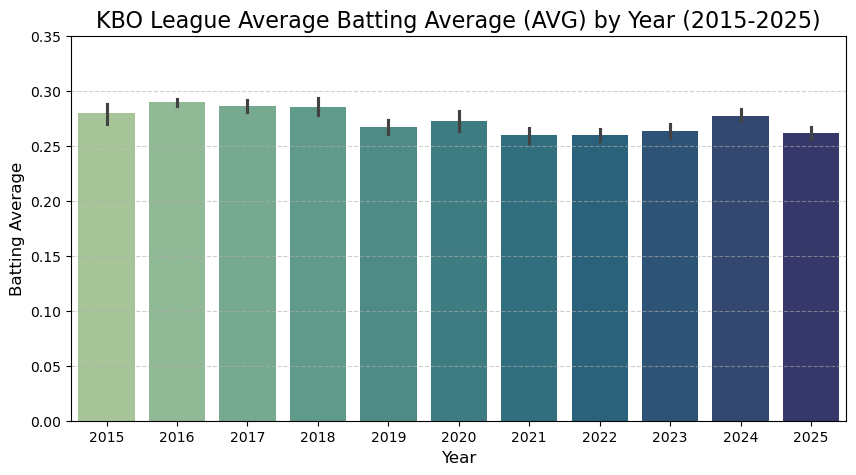

In [43]:
# League Average Batting Average (AVG) by Year (2010-2025) Chart
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df, 
    x="YEAR", 
    y="AVG", 
    hue="YEAR",
    palette="crest",
    legend=False
)

# Ensure Y-axis starts at 0
plt.ylim(0, 0.35)

# Add title and labels
plt.title("KBO League Average Batting Average (AVG) by Year (2015-2025)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Batting Average", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

In [12]:
# How about On-base Plus Slugging (OPS)?
print(f"Average OPS of last 11 seasons: {df['OPS'].mean():.3f}")

Average OPS of last 11 seasons: 0.756


In [13]:
# break down data by year
data = df[['YEAR', 'OPS']].groupby('YEAR', as_index=False).mean()
print(data)

    YEAR     OPS
0   2015  0.7860
1   2016  0.8012
2   2017  0.7907
3   2018  0.8022
4   2019  0.7214
5   2020  0.7572
6   2021  0.7289
7   2022  0.7124
8   2023  0.7121
9   2024  0.7715
10  2025  0.7272


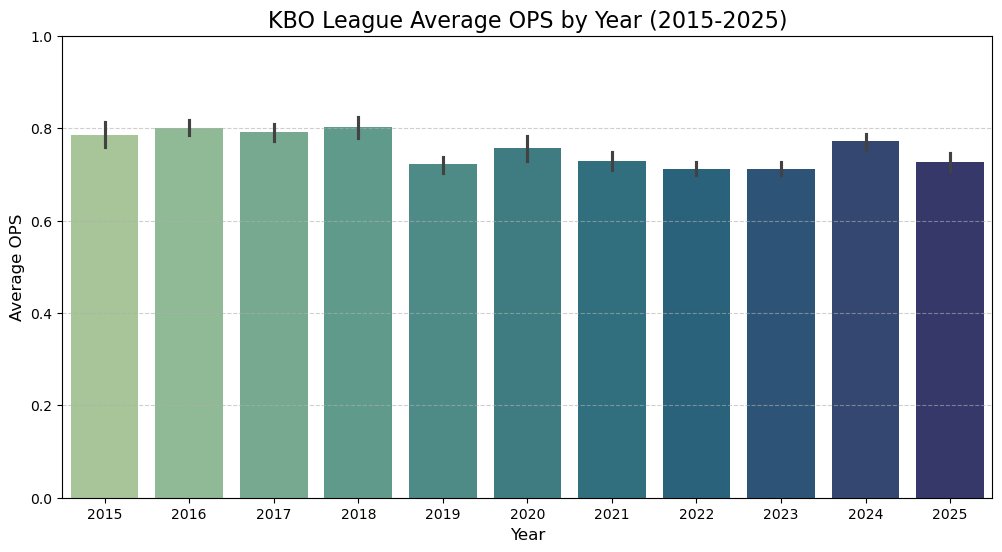

In [ ]:
# League OPS by Year (2015-2025) Chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df, 
    x="YEAR", 
    y="OPS", 
    hue="YEAR",
    legend=False,
    palette="crest"
)

# Ensure Y-axis starts at 0
plt.ylim(0, 1.0)

# Add title and labels
plt.title("KBO League Average OPS by Year (2015-2025)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average OPS", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [20]:
# Let's focus on Home Run
avg_homeruns = df['HR'].mean()
print(f"Average Home Run of last 15 seasons: {avg_homeruns:0.0f}, ")
print(f"{avg_homeruns / 144:.2f} per game")

Average Home Run of last 15 seasons: 132, 
0.91 per game


In [21]:
# break down data by year
data = df[['YEAR', 'HR']].groupby('YEAR', as_index=False).mean()
print(data)

    YEAR     HR
0   2015  151.1
1   2016  148.3
2   2017  154.7
3   2018  175.6
4   2019  101.4
5   2020  136.3
6   2021  115.8
7   2022  108.5
8   2023   92.4
9   2024  143.8
10  2025  119.1


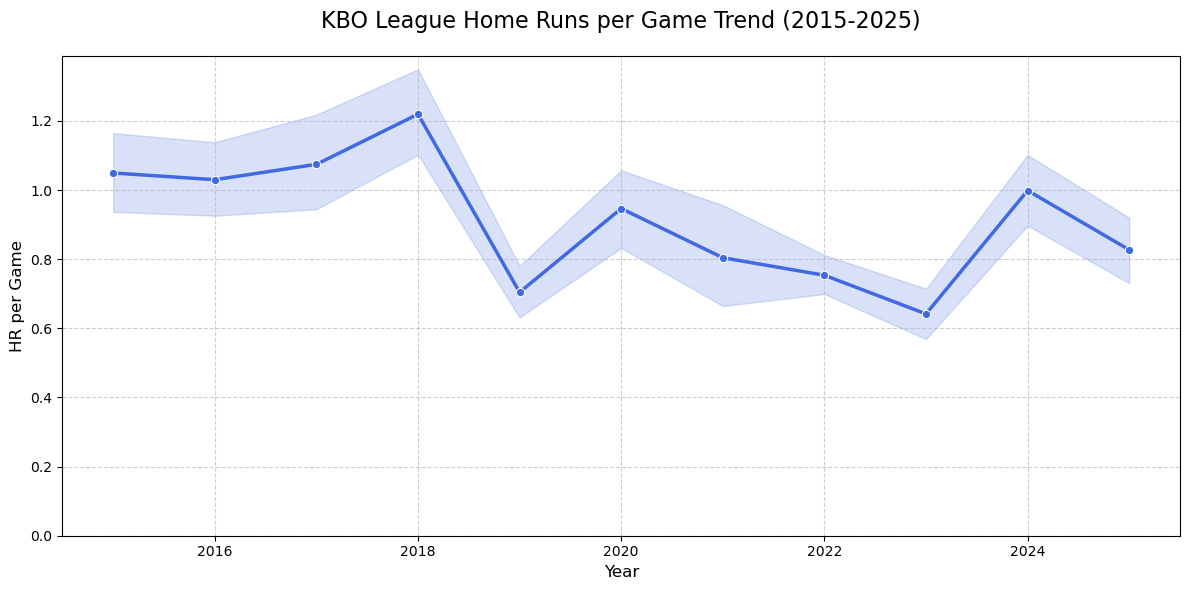

In [ ]:
# Line chart of HR per Game
plt.figure(figsize=(12, 6))

# Calculate HR per Game
df['HR_per_G'] = df['HR'] / df['G']

# plot a line chart
sns.lineplot(
    data=df, 
    x="YEAR", 
    y="HR_per_G",
    marker='o',
    color='royalblue',
    linewidth=2.5
)

# Styling and Axes
plt.ylim(0, None)  # Ensure the Y-axis starts at 0 to show true scale
plt.grid(True, linestyle='--', alpha=0.6)  # Add a light grid for readability

# Add Titles and Labels
plt.title("KBO League Home Runs per Game Trend (2015-2025)", fontsize=16, pad=20)
plt.xlabel("Year", fontsize=12)
plt.ylabel("HR per Game", fontsize=12)

# Final display
plt.tight_layout()
plt.show()

#### How about the pitchers?

In [48]:
# Average ERA (Earned Run Average) of last 11 seasons
print(f"Average ERA of last 11 seasons: {df['ERA'].mean():.2f}")

Average ERA of last 11 seasons: 4.63


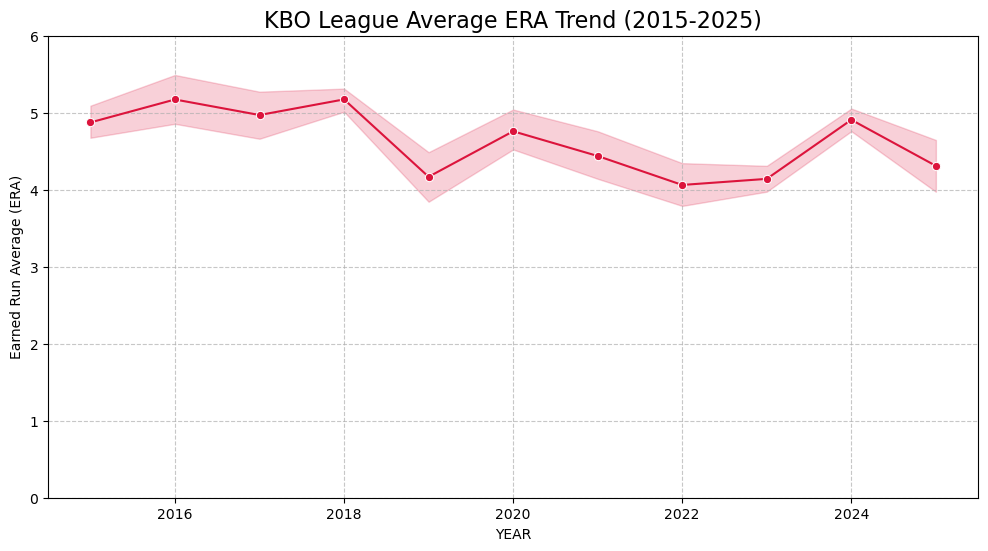

In [46]:
# League Average ERA by Year (2015-2025) Chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="YEAR", y="ERA", marker='o', color='crimson')
plt.ylim(0, 6) 
plt.title("KBO League Average ERA Trend (2015-2025)", fontsize=16)
plt.ylabel("Earned Run Average (ERA)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [49]:
# Average WHIP (Walks + Hits per Inning Pitched) of last 11 seasons
print(f"Average WHIP of last 11 seasons: {df['WHIP'].mean():.2f}")

Average WHIP of last 11 seasons: 1.46


In [50]:
# break down data by year
data = df[['YEAR', 'WHIP']].groupby('YEAR', as_index=False).mean()
print(data)

    YEAR   WHIP
0   2015  1.489
1   2016  1.557
2   2017  1.480
3   2018  1.494
4   2019  1.402
5   2020  1.476
6   2021  1.457
7   2022  1.382
8   2023  1.411
9   2024  1.500
10  2025  1.404


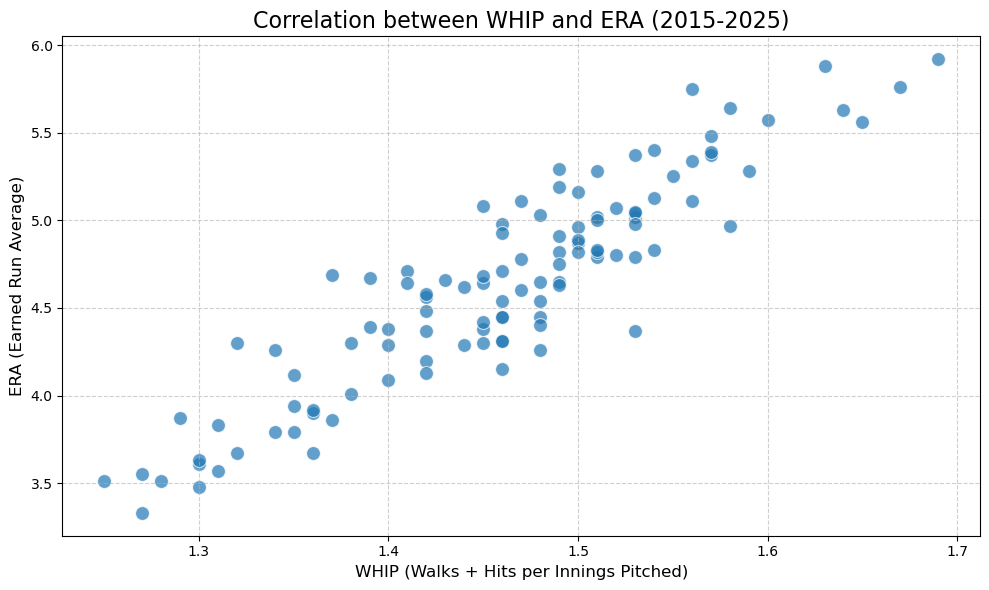

In [ ]:
# relationship between ERA and WHIP
plt.figure(figsize=(10, 6))

# draw a scatter plot
sns.scatterplot(
    data=df, 
    x="WHIP", 
    y="ERA", 
    s=100, 
    alpha=0.7
)

# add titles and labels
plt.title("Correlation between WHIP and ERA (2015-2025)", fontsize=16)
plt.xlabel("WHIP (Walks + Hits per Innings Pitched)", fontsize=12)
plt.ylabel("ERA (Earned Run Average)", fontsize=12)

# add grid
plt.grid(True, linestyle='--', alpha=0.6)

# show the chart
plt.tight_layout()
plt.show()

In [ ]:
# calculate CORR value
print(f"Correlation between WHIP and ERA: {df['WHIP'].corr(df['ERA']):.2f}")

Correlation between WHIP and ERA: 0.91


In [61]:
# Check the base on balls allowed
print(f"Average Base on Balls Allowed per Game of last 11 seasons: {df['BB_A'].mean() / 144:.2f}")

Average Base on Balls Allowed per Game of last 11 seasons: 3.55


In [ ]:
# Base on Balls Allowed 
# break down data by year
data = df[['YEAR', 'BB_A']].groupby('YEAR', as_index=True).mean() / 144
print(data)

          BB_A
YEAR          
2015  3.648611
2016  3.731250
2017  3.138889
2018  3.209722
2019  3.297917
2020  3.690278
2021  4.091667
2022  3.423611
2023  3.569444
2024  3.656250
2025  3.557639


In [67]:
# Check about the Runs Allowed
# break down data by year
data = df[['YEAR', 'R_A']].groupby('YEAR', as_index=True).mean() / 144
print(data)

           R_A
YEAR          
2015  5.276389
2016  5.606944
2017  5.334722
2018  5.551389
2019  4.547222
2020  5.163889
2021  4.788889
2022  4.529861
2023  4.598611
2024  5.375000
2025  4.731250


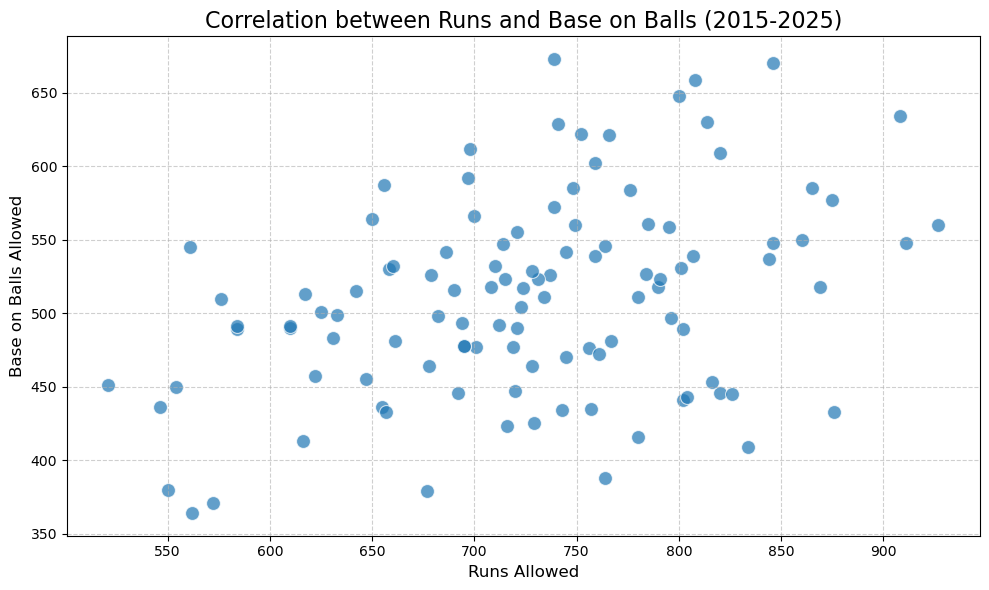

In [69]:
# Find relationship between Base on Balls and Runs Allowed
plt.figure(figsize=(10, 6))

# draw a scatter plot
sns.scatterplot(
    data=df, 
    x="R_A", 
    y="BB_A", 
    s=100, 
    alpha=0.7
)

# add titles and labels
plt.title("Correlation between Runs and Base on Balls (2015-2025)", fontsize=16)
plt.xlabel("Runs Allowed", fontsize=12)
plt.ylabel("Base on Balls Allowed", fontsize=12)

# add grid
plt.grid(True, linestyle='--', alpha=0.6)

# show the chart
plt.tight_layout()
plt.show()

In [70]:
# calculate CORR value
print(f"Correlation between Runs and Base on Balls: {df['R_A'].corr(df['BB_A']):.2f}")

Correlation between Runs and Base on Balls: 0.38


In [ ]:
# Check about the Hit Allowed per game
# break down data by year
data = df[['YEAR', 'H_A']].groupby('YEAR', as_index=True).mean() / 144
print(data)

            H_A
YEAR           
2015   9.586111
2016  10.111111
2017   9.997917
2018  10.031250
2019   9.128472
2020   9.407639
2021   8.726389
2022   8.889583
2023   9.006250
2024   9.672917
2025   8.905556


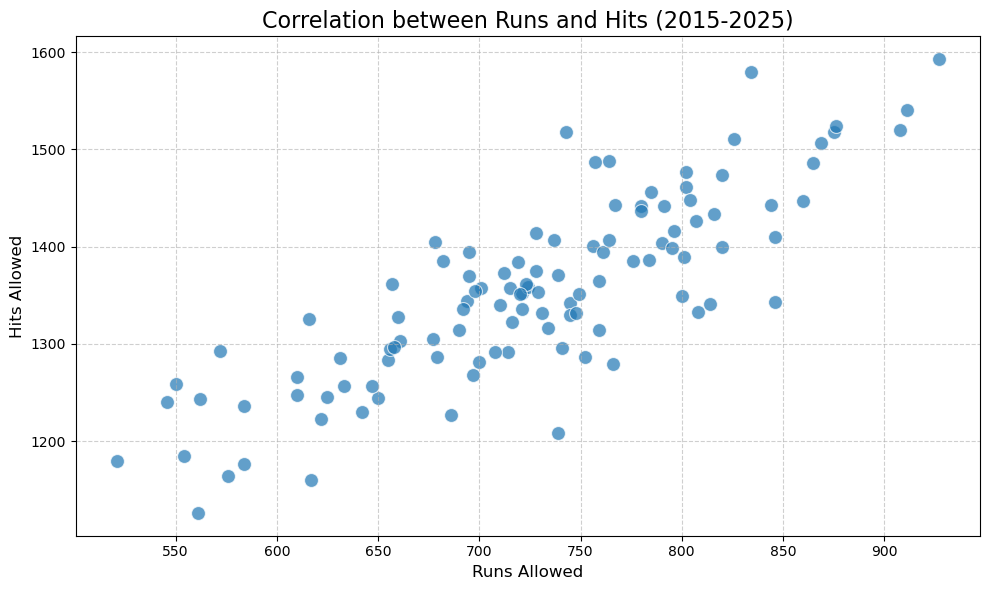

In [72]:
# Find relationship between Base on Balls and Runs Allowed
plt.figure(figsize=(10, 6))

# draw a scatter plot
sns.scatterplot(
    data=df, 
    x="R_A", 
    y="H_A", 
    s=100, 
    alpha=0.7
)

# add titles and labels
plt.title("Correlation between Runs and Hits (2015-2025)", fontsize=16)
plt.xlabel("Runs Allowed", fontsize=12)
plt.ylabel("Hits Allowed", fontsize=12)

# add grid
plt.grid(True, linestyle='--', alpha=0.6)

# show the chart
plt.tight_layout()
plt.show()

In [73]:
# calculate CORR value
print(f"Correlation between Runs and Base on Balls: {df['R_A'].corr(df['H_A']):.2f}")

Correlation between Runs and Base on Balls: 0.83
